# Weather Forecasting Machine Learning Project
Notebook created by: Ashlynn Blanshan

### importing the weather data set

In [ ]:
import pandas as pd

df = pd.read_csv("hf://datasets/Katherinetian/weather_data_NC/weather_data.csv")

df.head()
# df.to_csv('raw_data.csv', index=False)

c:\Users\Owner\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


Here we have the dataset, since we have null values we must find ways to deal with the missing values.

In [2]:
print(df.isna().sum()) 

dt                         0
main.temp                  0
main.feels_like            0
main.pressure              0
main.humidity              0
main.temp_min              0
main.temp_max              0
wind.speed                 0
wind.deg                   0
wind.gust              49237
clouds.all                 0
latitude                   0
longitude                  0
date                       0
rain.1h                74873
weather_id                 0
weather_main               0
weather_description        0
weather_icon               0
city                       0
snow.1h                78614
rain.3h                78622
dtype: int64


## Data Cleaning

#### Missing Values
Since wind gust, rain.1h, snow.1h, and rain.3h have majority of missing values, I think it is best we drop these columns in its entirety instead of using imputation techniques.

I am also dropping 'dt' because it is irrelevant and I want to end up using the date-time as the index.

In [3]:
df = df.drop(columns=["wind.gust", "rain.1h", "snow.1h", "rain.3h", "dt"], errors='ignore')
df.head()

,main.temp,main.feels_like,main.pressure,main.humidity,main.temp_min,main.temp_max,wind.speed,wind.deg,clouds.all,latitude,longitude,date,weather_id,weather_main,weather_description,weather_icon,city
0,281.21,279.60,1017,64,279.30,283.01,2.60,309,94,35.780398,-78.639099,2023-03-19,804,Clouds,overcast clouds,04n,"Raleigh,NC,US"
1,281.01,281.01,1016,50,278.29,282.96,0.00,0,75,35.780398,-78.639099,2023-03-19,803,Clouds,broken clouds,04n,"Raleigh,NC,US"
2,280.25,279.44,1015,49,277.93,281.96,1.54,310,75,35.780398,-78.639099,2023-03-19,803,Clouds,broken clouds,04n,"Raleigh,NC,US"
3,280.69,279.01,1016,45,278.26,281.96,2.57,0,75,35.780398,-78.639099,2023-03-19,803,Clouds,broken clouds,04n,"Raleigh,NC,US"
4,280.03,278.92,1016,45,277.71,281.96,1.79,38,75,35.780398,-78.639099,2023-03-19,803,Clouds,broken clouds,04n,"Raleigh,NC,US"


In [4]:
# since we want to predict temperature using time-series analysis, it will be beneficial
# to convert the date column to a pandas date-time data type
print(df.dtypes)


main.temp              float64
main.feels_like        float64
main.pressure            int64
main.humidity            int64
main.temp_min          float64
main.temp_max          float64
wind.speed             float64
wind.deg                 int64
clouds.all               int64
latitude               float64
longitude              float64
date                       str
weather_id               int64
weather_main               str
weather_description        str
weather_icon               str
city                       str
dtype: object


In [5]:
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')
print(df.dtypes)

main.temp                     float64
main.feels_like               float64
main.pressure                   int64
main.humidity                   int64
main.temp_min                 float64
main.temp_max                 float64
wind.speed                    float64
wind.deg                        int64
clouds.all                      int64
latitude                      float64
longitude                     float64
date                   datetime64[us]
weather_id                      int64
weather_main                      str
weather_description               str
weather_icon                      str
city                              str
dtype: object


#### Plotting the Data

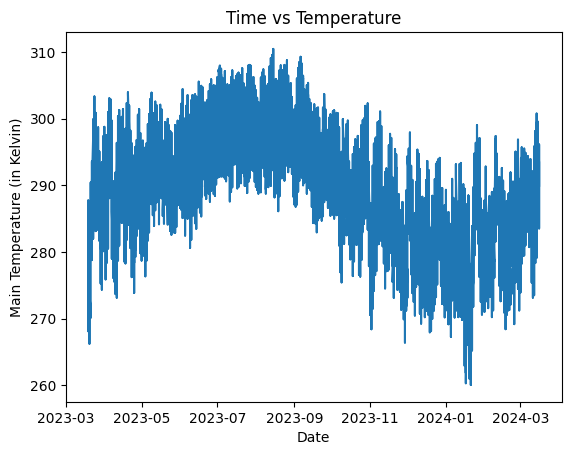

In [6]:
import matplotlib.pyplot as plt

x = df["date"]
y = df["main.temp"]

plt.plot(x, y)
plt.xlabel("Date")
plt.ylabel("Main Temperature (in Kelvin)")
plt.title("Time vs Temperature")
plt.show()

#### Correlation Matrix

<Axes: >

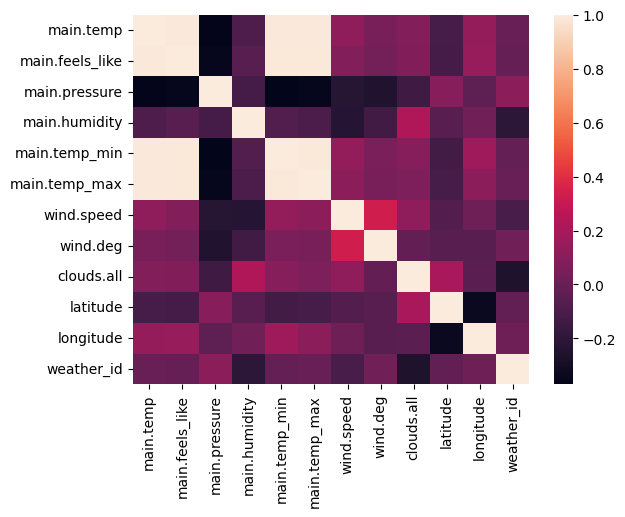

In [7]:
import seaborn as sns

df_num = df.drop(columns=['date', 'weather_main' , 'weather_description' , 'weather_icon' , 'city'])
corr_matrix = df_num.corr(numeric_only=True)

sns.heatmap(data=corr_matrix)

#### Dropping Irrelevant Columns
Looking at this correlation matrix, I realized that we should drop the "main.feels_like", "main.temp_min" and "main.temp_max" columns since they are basically derived from the temperature and we are trying to make a model that accurately predicts the temperature.

In [8]:
df = df.drop(columns=['main.feels_like' , 'main.temp_min', 'main.temp_max'])
df.head()

,main.temp,main.pressure,main.humidity,wind.speed,wind.deg,clouds.all,latitude,longitude,date,weather_id,weather_main,weather_description,weather_icon,city
0,281.21,1017,64,2.60,309,94,35.780398,-78.639099,2023-03-19,804,Clouds,overcast clouds,04n,"Raleigh,NC,US"
17484,283.21,1019,46,0.89,291,64,35.108493,-77.044114,2023-03-19,803,Clouds,broken clouds,04d,"New Bern,NC,US"
17483,282.06,1019,50,0.89,285,84,35.108493,-77.044114,2023-03-19,803,Clouds,broken clouds,04d,"New Bern,NC,US"
17482,281.32,1020,59,4.59,346,92,35.108493,-77.044114,2023-03-19,804,Clouds,overcast clouds,04d,"New Bern,NC,US"
17480,280.91,1018,60,4.18,347,96,35.108493,-77.044114,2023-03-19,804,Clouds,overcast clouds,04d,"New Bern,NC,US"


In [9]:
weather = df["weather_main"].unique()

for i in weather:
    count = (df["weather_main"] == i).sum()
    print("the number of entries for " , i , " is ", count)

the number of entries for  Clouds  is  43628
the number of entries for  Clear  is  27959
the number of entries for  Rain  is  3379
the number of entries for  Smoke  is  122
the number of entries for  Fog  is  325
the number of entries for  Mist  is  2046
the number of entries for  Drizzle  is  341
the number of entries for  Thunderstorm  is  317
the number of entries for  Haze  is  496
the number of entries for  Snow  is  10
the number of entries for  Squall  is  1


#### Encoding
I am going to get rid of irrelevant weather types based upon their value count into "other" so that we still include them since we are dealing with time-series data, and to prevent noise. Then I am going to encode the variable into numerical variables using pandas dummy variable function.

In [10]:
counts = df['weather_main'].value_counts()
irr = counts[counts < 500].index

df['weather_main'] = df['weather_main'].replace(irr, 'Other')

df = pd.get_dummies(df, columns=['weather_main'], drop_first=True)

df.head()

,main.temp,main.pressure,main.humidity,wind.speed,wind.deg,clouds.all,latitude,longitude,date,weather_id,weather_description,weather_icon,city,weather_main_Clouds,weather_main_Mist,weather_main_Other,weather_main_Rain
0,281.21,1017,64,2.60,309,94,35.780398,-78.639099,2023-03-19,804,overcast clouds,04n,"Raleigh,NC,US",True,False,False,False
17484,283.21,1019,46,0.89,291,64,35.108493,-77.044114,2023-03-19,803,broken clouds,04d,"New Bern,NC,US",True,False,False,False
17483,282.06,1019,50,0.89,285,84,35.108493,-77.044114,2023-03-19,803,broken clouds,04d,"New Bern,NC,US",True,False,False,False
17482,281.32,1020,59,4.59,346,92,35.108493,-77.044114,2023-03-19,804,overcast clouds,04d,"New Bern,NC,US",True,False,False,False
17480,280.91,1018,60,4.18,347,96,35.108493,-77.044114,2023-03-19,804,overcast clouds,04d,"New Bern,NC,US",True,False,False,False


#### Dropping More Columns

In [11]:
df = df.drop(columns=['weather_description' , 'weather_id', 'weather_description', 'weather_icon'])
df.head()

,main.temp,main.pressure,main.humidity,wind.speed,wind.deg,clouds.all,latitude,longitude,date,city,weather_main_Clouds,weather_main_Mist,weather_main_Other,weather_main_Rain
0,281.21,1017,64,2.60,309,94,35.780398,-78.639099,2023-03-19,"Raleigh,NC,US",True,False,False,False
17484,283.21,1019,46,0.89,291,64,35.108493,-77.044114,2023-03-19,"New Bern,NC,US",True,False,False,False
17483,282.06,1019,50,0.89,285,84,35.108493,-77.044114,2023-03-19,"New Bern,NC,US",True,False,False,False
17482,281.32,1020,59,4.59,346,92,35.108493,-77.044114,2023-03-19,"New Bern,NC,US",True,False,False,False
17480,280.91,1018,60,4.18,347,96,35.108493,-77.044114,2023-03-19,"New Bern,NC,US",True,False,False,False


## Feature Engineering
Since we are using time series data, it is important to create features in relation to time that can help predict the temperature. There a many techniques out there such as lag features, rolling features, time features, etc. 

In [12]:
# since we will be getting rid of the date time column for ML, it is good to make time based features.

df['year'] = df['date'].dt.year
df['quarter'] = df['date'].dt.quarter
df['month'] = df['date'].dt.month
df['week'] = df['date'].dt.isocalendar().week.astype(int)
df['day'] = df['date'].dt.day

df.head()

,main.temp,main.pressure,main.humidity,wind.speed,wind.deg,clouds.all,latitude,longitude,date,city,weather_main_Clouds,weather_main_Mist,weather_main_Other,weather_main_Rain,year,quarter,month,week,day
0,281.21,1017,64,2.60,309,94,35.780398,-78.639099,2023-03-19,"Raleigh,NC,US",True,False,False,False,2023,1,3,11,19
17484,283.21,1019,46,0.89,291,64,35.108493,-77.044114,2023-03-19,"New Bern,NC,US",True,False,False,False,2023,1,3,11,19
17483,282.06,1019,50,0.89,285,84,35.108493,-77.044114,2023-03-19,"New Bern,NC,US",True,False,False,False,2023,1,3,11,19
17482,281.32,1020,59,4.59,346,92,35.108493,-77.044114,2023-03-19,"New Bern,NC,US",True,False,False,False,2023,1,3,11,19
17480,280.91,1018,60,4.18,347,96,35.108493,-77.044114,2023-03-19,"New Bern,NC,US",True,False,False,False,2023,1,3,11,19


In [13]:
# from researching time series forecasting, cyclical encoding is great with time since time in nature is cyclical
import numpy as np

df['day_sin'] = np.sin(2 * np.pi * df['day'] / 7)
df['day_cos'] = np.cos(2 * np.pi * df['day'] / 7)

df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

In [ ]:
# lag features, another good feature engineering method for time series forecasting

df['lag_1'] = df['main.temp'].shift(1)
df['lag_2'] = df['main.temp'].shift(2)
df['lag_7'] = df['main.temp'].shift(7)

df.head()
#df.to_csv('cleaned_data.csv', index=False)

In [15]:
city_names = df["city"].unique()

for i in city_names:
    count = (df["city"] == i).sum()
    print("the number of entries for " , i , " is ", count)

the number of entries for  Raleigh,NC,US  is  8736
the number of entries for  New Bern,NC,US  is  8736
the number of entries for  Wilmington,NC,US  is  8736
the number of entries for  Asheville,NC,US  is  8736
the number of entries for  Winnabow,NC,USChapel Hill,NC,US  is  8736
the number of entries for  Greensboro,NC,US  is  8736
the number of entries for  Charlotte,NC,US  is  8736
the number of entries for  Durham,NC,US  is  8736
the number of entries for  Greenville,NC,US  is  8736


#### Narrowing it down to a city

I am thinking for now is to focus on one city, I am going to pick Asheville to create a baseline prediction model.

In [ ]:
df_asheville = df[df["city"] == 'Asheville,NC,US']
df_asheville.head()
# df_asheville.to_csv('cleaned_data_asheville.csv', index=False)

## Modeling

### Linear Regression

In [ ]:
#Train/Test split

split = int(len(df_asheville) * 0.8)

train = df_asheville.iloc[:split]
test = df_asheville.iloc[split:]

X_train = train.drop(columns=['main.temp', 'date', 'city'])
y_train = train['main.temp']

X_test = test.drop(columns=['main.temp', 'date', 'city'])
y_test = test['main.temp']

# X_train.to_csv('X_train.csv', index=False)
# y_train.to_csv('y_train.csv', index=False)
# X_test.to_csv('X_test.csv', index=False)
# y_test.to_csv('y_test.csv', index=False)


In [18]:
# linear regression
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [19]:
y_pred = lin_reg.predict(X_test)

In [20]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, accuracy_score


mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R^2: {r2:.4f}")

MAE: 2.4547
RMSE: 3.2375
R^2: 0.7670


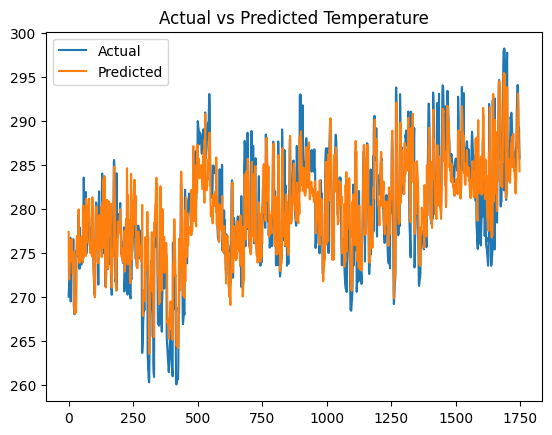

In [21]:

plt.figure()

plt.plot(y_test.values, label='Actual')
plt.plot(y_pred, label='Predicted')

plt.legend()
plt.title('Actual vs Predicted Temperature')
plt.show()

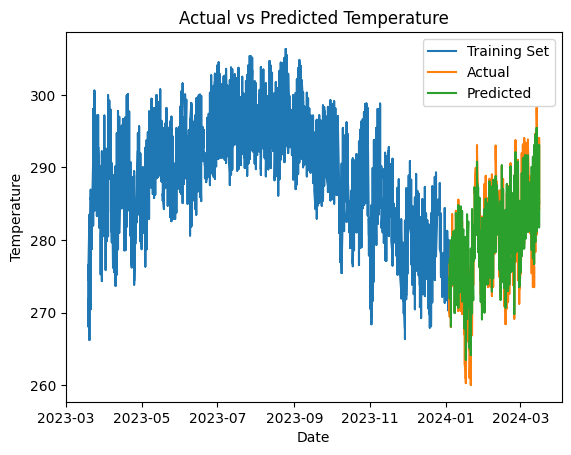

In [22]:

plt.figure()

# Training data
plt.plot(train['date'], y_train, label='Training Set')

# Actual test values
plt.plot(test['date'], y_test.values, label='Actual')

# Predicted values
plt.plot(test['date'], y_pred, label='Predicted')

plt.legend()
plt.title('Actual vs Predicted Temperature')
plt.xlabel('Date')
plt.ylabel('Temperature')

plt.show()

Overall pretty good baseline linear regression model, the MAE and RMSE suggest that the model predictions is off by a few kelvin which is pretty accurate. Since we are using linear regression it may good to test out either ridge or lasso regression before going to more advanced models such as tree based regressors (XGBoost is a good example) or LSTM's.

In [23]:
from sklearn.linear_model import Lasso

lin_reg_lasso = Lasso(random_state=42)
lin_reg_lasso.fit(X_train, y_train)

,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary `.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",42
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


In [24]:
y_pred = lin_reg_lasso.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R^2: {r2:.4f}")

MAE: 2.2511
RMSE: 3.2161
R^2: 0.7701


Performed Lasso, got simliar results

In [25]:
from sklearn.linear_model import Ridge

lin_reg_ridge = Ridge(random_state=42)
lin_reg_ridge.fit(X_train, y_train)

,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details... versionadded:: 0.17 `random_state` to support Stochastic Average Gradient.",42


In [26]:
y_pred = lin_reg_ridge.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R^2: {r2:.4f}")

MAE: 2.4547
RMSE: 3.2365
R^2: 0.7672


Here I performed Ridge Regression, got simliar results, proof that while linear regression is a good baseline, it is important to branch out to more elaborate models.

### XGBoost 
Now I want to move onto more complex models that are useful for time-series forecasting. Looking into it, I discovered that XGBoost is a great model for it since it is an ensemble tree method that expands upon random forest models by using a sliding window approach.

In [27]:
from xgboost import XGBRegressor


model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)

model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Optional[float]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[str], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = lo

In [28]:
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R^2: {r2:.4f}")

MAE: 2.3311
RMSE: 3.1812
R^2: 0.7751


In [29]:
for depth in [2, 3, 4, 5, 6, 7]:
    model = XGBRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=depth,
        random_state=42
    )
    
    model.fit(X_train, y_train, verbose=False)
    y_pred = model.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    print(f"Depth {depth}: R^2: {r2:.4f}")
    

Depth 2: R^2: 0.7873
Depth 3: R^2: 0.8033
Depth 4: R^2: 0.7797
Depth 5: R^2: 0.7751
Depth 6: R^2: 0.7474
Depth 7: R^2: 0.7326


In [30]:
for lr in [0.01, 0.03, 0.04, 0.05, 0.07]:
    model = XGBRegressor(
        n_estimators=200,
        learning_rate=lr,
        max_depth=3,
        random_state=42
    )
    
    model.fit(X_train, y_train, verbose=False)
    y_pred = model.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    print(f"Learning Rate {lr}: R^2: {r2:.4f}")

Learning Rate 0.01: R^2: 0.6431
Learning Rate 0.03: R^2: 0.7937
Learning Rate 0.04: R^2: 0.7974
Learning Rate 0.05: R^2: 0.8033
Learning Rate 0.07: R^2: 0.7785


In [31]:
for n in [100, 200, 500, 1000]:
    model = XGBRegressor(
        n_estimators=n,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )
    
    model.fit(X_train, y_train, verbose=False)
    y_pred = model.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    print(f"n_estimators {n}: R^2: {r2:.4f}")

n_estimators 100: R^2: 0.7791
n_estimators 200: R^2: 0.8033
n_estimators 500: R^2: 0.7856
n_estimators 1000: R^2: 0.6675


In [32]:
for subsample in [0.6, 0.8, 1.0]:
    for colsample in [0.6, 0.8, 1.0]:
        
        model = XGBRegressor(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=3,
            subsample=subsample,
            colsample_bytree=colsample,
            random_state=42
        )
        
        model.fit(X_train, y_train, verbose=False)
        y_pred = model.predict(X_test)

        r2 = r2_score(y_test, y_pred)
        print(f"Subsample: {subsample} and Colsample:{colsample} : R^2: {r2:.4f}")

Subsample: 0.6 and Colsample:0.6 : R^2: 0.8017
Subsample: 0.6 and Colsample:0.8 : R^2: 0.7969
Subsample: 0.6 and Colsample:1.0 : R^2: 0.7987
Subsample: 0.8 and Colsample:0.6 : R^2: 0.8033
Subsample: 0.8 and Colsample:0.8 : R^2: 0.8031
Subsample: 0.8 and Colsample:1.0 : R^2: 0.8036
Subsample: 1.0 and Colsample:0.6 : R^2: 0.8069
Subsample: 1.0 and Colsample:0.8 : R^2: 0.8081
Subsample: 1.0 and Colsample:1.0 : R^2: 0.8033


In [33]:
for alpha in [0, 0.1, 1]:
    for lam in [1, 5, 10]:
        
        model = XGBRegressor(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=3,
            subsample=1.0,
            #colsample=0.8,
            reg_alpha=alpha,
            reg_lambda=lam,
            random_state=42
        )

        model.fit(X_train, y_train, verbose=False)
        y_pred = model.predict(X_test)

        r2 = r2_score(y_test, y_pred)
        print(f"Alpha: {alpha} and Lambda:{lam} : R^2: {r2:.4f}")


Alpha: 0 and Lambda:1 : R^2: 0.8033
Alpha: 0 and Lambda:5 : R^2: 0.8072
Alpha: 0 and Lambda:10 : R^2: 0.8063
Alpha: 0.1 and Lambda:1 : R^2: 0.7905
Alpha: 0.1 and Lambda:5 : R^2: 0.8046
Alpha: 0.1 and Lambda:10 : R^2: 0.8053
Alpha: 1 and Lambda:1 : R^2: 0.7964
Alpha: 1 and Lambda:5 : R^2: 0.8076
Alpha: 1 and Lambda:10 : R^2: 0.8066


In [34]:
final_xgb = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    subsample=1.0,
    colsample_bytree=0.8,
    reg_alpha=1,
    reg_lambda=10,
    random_state=42
)

final_xgb.fit(X_train, y_train)
y_pred = final_xgb.predict(X_test)

r2 = r2_score(y_test, y_pred)
print(f"Final R^2: {r2:.4f}")


Final R^2: 0.8036


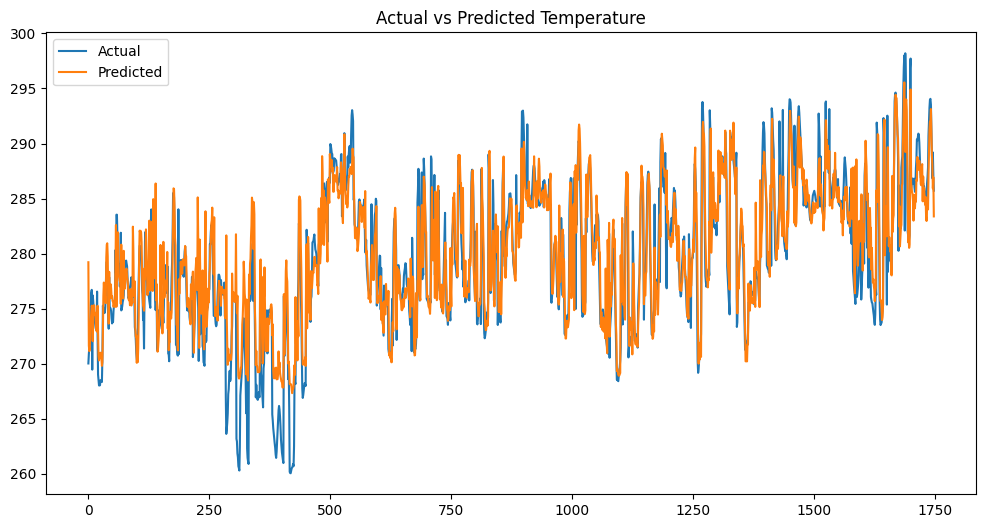

In [35]:

plt.figure(figsize=(12,6))

plt.plot(y_test.values, label='Actual')
plt.plot(y_pred, label='Predicted')

plt.legend()
plt.title('Actual vs Predicted Temperature')
plt.show()

### Testing the Model on all Other Cities

In [51]:
cities = [city for city in df['city'].unique() if city != 'Asheville,NC,US']

results = []

for city in cities:
    city_df = df[df['city'] == city].copy()
    split = int(len(city_df) * 0.8)

    train = city_df.iloc[:split]
    test = city_df.iloc[split:]

    X_train = train.drop(columns=['main.temp', 'date', 'city'])
    y_train = train['main.temp']

    X_test = test.drop(columns=['main.temp', 'date', 'city'])
    y_test = test['main.temp']

    y_pred = final_xgb.predict(X_test)

    
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results.append({
        'City': city,
        'MAE': round(mae, 4),
        'RMSE': round(rmse, 4),
        'R2': round(r2, 4)
    })

    print(f"{city}")
    print(f"MAE:  {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"R²:   {r2:.4f}")
    print("-" * 40)

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(by='R2', ascending=False)

print(results_df)

Raleigh,NC,US
MAE:  1.9530
RMSE: 2.6899
R²:   0.8290
----------------------------------------
New Bern,NC,US
MAE:  2.2800
RMSE: 3.1565
R²:   0.7354
----------------------------------------
Wilmington,NC,US
MAE:  2.4921
RMSE: 3.3006
R²:   0.7095
----------------------------------------
Winnabow,NC,USChapel Hill,NC,US
MAE:  2.4341
RMSE: 3.2265
R²:   0.6851
----------------------------------------
Greensboro,NC,US
MAE:  2.2288
RMSE: 3.1569
R²:   0.7692
----------------------------------------
Charlotte,NC,US
MAE:  2.0217
RMSE: 2.7574
R²:   0.8070
----------------------------------------
Durham,NC,US
MAE:  2.1472
RMSE: 2.9324
R²:   0.7989
----------------------------------------
Greenville,NC,US
MAE:  2.2379
RMSE: 3.0646
R²:   0.7884
----------------------------------------
                              City     MAE    RMSE      R2
0                    Raleigh,NC,US  1.9530  2.6899  0.8290
5                  Charlotte,NC,US  2.0217  2.7574  0.8070
6                     Durham,NC,US  2.1472

### LSTM

In [40]:
df_model = df_asheville.drop(columns=['date', 'city'])

In [41]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df_model)

In [42]:
import numpy as np

def create_sequences(data, seq_length=24):
    X, y = [], []
    
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length, 0])  
    return np.array(X), np.array(y)

X, y = create_sequences(scaled_data, seq_length=24)

In [43]:
split = int(len(X) * 0.8)

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [44]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(X.shape[1], X.shape[2])),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(1)
])

model.compile(
    optimizer='adam',
    loss='mse'
)

c:\Users\Owner\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [45]:
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/20
218/218 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - loss: 0.0234 - val_loss: 0.0126
Epoch 2/20
218/218 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0123 - val_loss: 0.0102
Epoch 3/20
218/218 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0102 - val_loss: 0.0087
Epoch 4/20
218/218 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 0.0091 - val_loss: 0.0149
Epoch 5/20
218/218 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0084 - val_loss: 0.0116
Epoch 6/20
218/218 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0078 - val_loss: 0.0081
Epoch 7/20
218/218 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0072 - val_loss: 0.0090
Epoch 8/20
218/218 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 0.0070 - val_loss: 0.0071
Epoch 9/20
218/218 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 0.0065 - val_loss: 0.0080
Epoch 10/20
218/218 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 0.0064 - val_loss: 0.0069
Epoch 11/20
218/218 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0059 - val_loss: 0.0109
Epoch 12/20
218/218 ━━━━━━━━━━━━━━━━━━━━ 

In [46]:
y_pred = model.predict(X_test)

55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step


In [47]:
dummy = np.zeros((len(y_pred), df_model.shape[1]))
dummy[:, 0] = y_pred.flatten()

y_pred_actual = scaler.inverse_transform(dummy)[:, 0]

dummy[:, 0] = y_test
y_test_actual = scaler.inverse_transform(dummy)[:, 0]

In [48]:
mae = mean_absolute_error(y_test_actual, y_pred_actual)
rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))
r2 = r2_score(y_test_actual, y_pred_actual)

print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R^2: {r2:.4f}")

MAE: 3.3367
RMSE: 4.3084
R^2: 0.5869


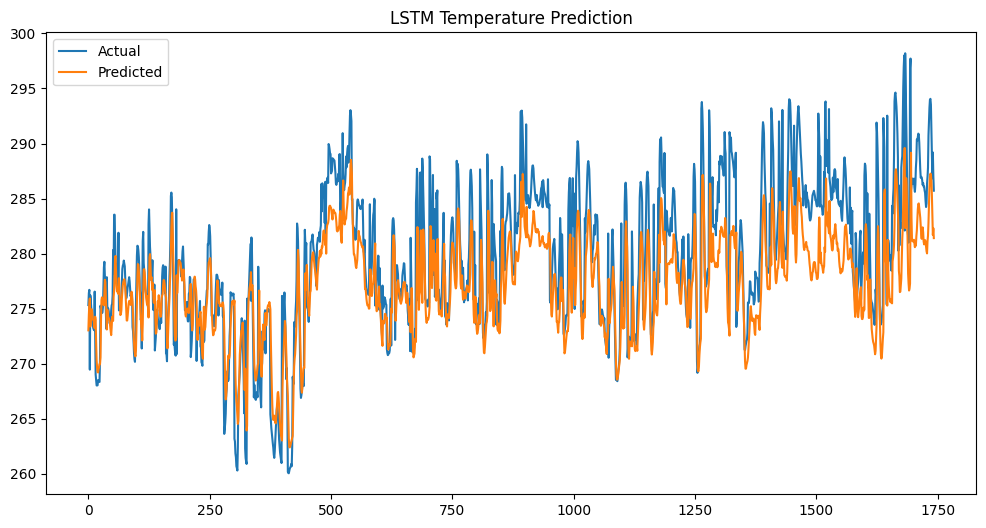

In [49]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(y_test_actual, label='Actual')
plt.plot(y_pred_actual, label='Predicted')

plt.title("LSTM Temperature Prediction")
plt.legend()
plt.show()

Looking at this, XGBoost is our best model. I now want to evaluate our best model onto all the other cities to look at how it does.

### Feauture Importance

<Figure size 1000x800 with 0 Axes>

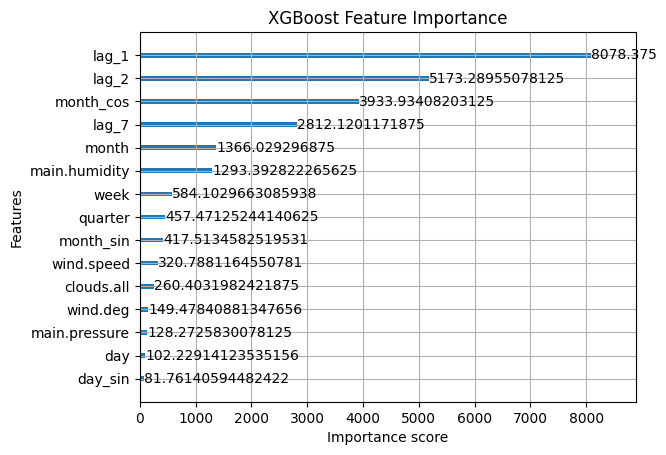

In [50]:
from xgboost import plot_importance
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

plot_importance(
    final_xgb,
    max_num_features=15,
    importance_type='gain'
)

plt.title("XGBoost Feature Importance")
plt.show()